# Estudio por simulación — Random Forest aplicado a California Housing

Se analiza cómo afectan los hiperparámetros `max_depth` y `n_estimators` de un
Random Forest al error de predicción, al sesgo², a la varianza y al tiempo de
entrenamiento, aplicado al problema de **predicción del valor medio de viviendas
en distritos de California**.


## Etapa 1 — Formulación del problema

**Pregunta de investigación:** ¿Cómo afectan `max_depth` y `n_estimators` al MSE
de test, al sesgo², a la varianza y al costo computacional de un Random Forest
aplicado a la predicción del valor medio de viviendas en California?

**Objetivos:**
1. Cuantificar cómo varía el MSE de test al modificar `max_depth` y `n_estimators`.
2. Estimar las componentes sesgo² y varianza del error para visualizar el trade-off sesgo-varianza.
3. Medir el costo computacional y su crecimiento con `n_estimators`.
4. Detectar sobreajuste comparando el desempeño en entrenamiento y en test.

**Hipótesis:**
- **H1:** El MSE_test tendrá un mínimo para algún `max_depth` intermedio. Para valores bajos dominará el sesgo; para valores altos la cantidad de arboles controlará la varianza y la curva se estabilizará.
- **H2:** El MSE_test disminuirá al aumentar `n_estimators` con rendimientos decrecientes.
- **H3:** El tiempo de entrenamiento crecerá de forma aproximadamente lineal con `n_estimators`.

**Justificación:** `max_depth` controla la complejidad individual de los árboles (sesgo-varianza),
mientras que `n_estimators` controla la cantidad de árboles del modelo (varianza y costo). Son los dos
hiperparámetros con interpretación más directa para los objetivos del estudio.


## Etapa 2 — Modelización conceptual

| Elemento | Definición |
|---|---|
| **Unidad de análisis** | Vivienda de California. (n = 20.640) |
| **Variables de entrada** | MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude |
| **Variable respuesta** | Valor medio de viviendas (en cientos de miles de dólares, escala 0.15–5.0) |
| **Algoritmo** | Random Forest para regresión (`RandomForestRegressor`) |
| **Factores que varían** | `max_depth` ∈ {2, 3, 5, 7, 10, 15, 20, None} · `n_estimators` ∈ {10, 25, 50, 100, 200, 300, 500} |
| **Factores fijos** | `max_features="sqrt"`, `min_samples_leaf=1`, `bootstrap=True`, `TEST_SIZE=0.30`, `N_REPLICAS=30` |
| **Fuentes de aleatoriedad** | Partición train/test por réplica + aleatoriedad interna del Random Forest |
| **Salidas** | MSE_train, MSE_test, RMSE_test, R²_test, tiempo (s), sesgo², varianza, error irreducible |

**Supuestos:**
1. Los 20.640 distritos son representativos de California y sus observaciones son independientes.
2. La relación entre las variables del censo y el valor de la vivienda es estable.
3. El MSE de test sobre particiones independientes estima razonablemente el error de generalización.
4. Las réplicas con distintas particiones train/test permiten estimar la variabilidad del desempeño.


## Etapa 3 — Datos y configuración

### Dataset: California Housing

Fuente: censo de California 1990, incluido en scikit-learn (`fetch_california_housing`).

- **20.640 distritos**, **8 variables predictoras** del censo (ingreso, edad de las casas,
  promedio de habitaciones y dormitorios, población, ocupantes por hogar, latitud y longitud).
- **Variable respuesta:** valor medio de la vivienda en el distrito, en cientos de miles de USD
  (escala 0.15–5.0, media ≈ 2.07, desvío estándar ≈ 1.15).
- Sin valores faltantes.

La aleatoriedad proviene de las distintas particiones train/test en cada réplica y de la
aleatoriedad interna del Random Forest (bootstrap de filas y selección de features por split).


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [11]:
# Carga del dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="valor_vivienda")

print("Dimensiones:", X.shape)
print("\nEstadísticas de la variable respuesta:")
print(y.describe().round(2))
print(f"\nValores faltantes: {X.isna().sum().sum()}")


Dimensiones: (20640, 8)

Estadísticas de la variable respuesta:
count    20640.00
mean         2.07
std          1.15
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: valor_vivienda, dtype: float64

Valores faltantes: 0


## Etapa 4 — Diseño de escenarios

Se evalúa un diseño factorial completo: se prueban todas las combinaciones posibles de max_depth y n_estimators, lo que da 8 × 7 = 56 escenarios distintos. Para cada escenario se corren 30 réplicas con distintas particiones train/test. En total se realizan 8 × 7 × 30 = 1.680 entrenamientos.

In [12]:
# Parámetros del estudio
SEED        = 42
TEST_SIZE   = 0.30
N_REPLICAS  = 30

max_depth_grid    = [2, 3, 5, 7, 10, 15, 20, None]
n_estimators_grid = [10, 25, 50, 100, 200, 300, 500]

params_fijos = {"max_features": "sqrt", "min_samples_leaf": 1, "bootstrap": True}

total = len(max_depth_grid) * len(n_estimators_grid) * N_REPLICAS
print(f"Total de entrenamientos: {len(max_depth_grid)} × {len(n_estimators_grid)} × {N_REPLICAS} = {total}")


Total de entrenamientos: 8 × 7 × 30 = 1680


## Etapa 5 — Implementación

### Métricas

Se usa el **MSE** como métrica principal porque admite la descomposición
sesgo² + varianza + error irreducible, que es el eje central del análisis.
El modelo nulo (predecir siempre la media) tiene MSE ≈ Var(y) ≈ 1.15² ≈ 1.32.
Un MSE_test de 0.25 equivale a RMSE ≈ 0.50, es decir, error de ±50.000 USD en promedio.


In [13]:
def calcular_metricas(modelo, X_train, X_test, y_train, y_test):
    """Calcula MSE, RMSE y R² en train y test."""
    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)
    return {
        "mse_train": np.mean((y_train.values - pred_train) ** 2),
        "mse_test":  np.mean((y_test.values  - pred_test)  ** 2),
        "rmse_test": np.sqrt(np.mean((y_test.values - pred_test) ** 2)),
        "r2_test":   r2_score(y_test, pred_test)
    }


def correr_replica(X, y, max_depth, n_estimators, replica):
    """Entrena el modelo en una réplica y devuelve métricas + tiempo."""
    seed = SEED + replica
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=seed
    )
    modelo = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        random_state=seed, n_jobs=-1, **params_fijos
    )
    t0 = perf_counter()
    modelo.fit(X_train, y_train)
    tiempo = perf_counter() - t0

    resultado = {"max_depth": max_depth, "n_estimators": n_estimators,
                 "replica": replica, "tiempo_s": tiempo}
    resultado.update(calcular_metricas(modelo, X_train, X_test, y_train, y_test))
    return resultado


### Verificación con una réplica de prueba

In [14]:
prueba = correr_replica(X, y, max_depth=10, n_estimators=100, replica=0)

print(f"MSE_train = {prueba['mse_train']:.3f}")
print(f"MSE_test  = {prueba['mse_test']:.3f}")
print(f"RMSE_test = {prueba['rmse_test']:.3f}")
print(f"R²_test   = {prueba['r2_test']:.3f}")
print(f"Tiempo    = {prueba['tiempo_s']:.3f} s")


MSE_train = 0.209
MSE_test  = 0.304
RMSE_test = 0.551
R²_test   = 0.768
Tiempo    = 0.189 s


## Etapa 6 — Experimentación

### Simulación principal


In [15]:
resultados = []

for max_depth in max_depth_grid:
    for n_estimators in n_estimators_grid:
        print(f"max_depth={max_depth} | n_estimators={n_estimators}")
        for replica in range(N_REPLICAS):
            resultados.append(correr_replica(X, y, max_depth, n_estimators, replica))

df = pd.DataFrame(resultados)

# Columna auxiliar para graficar max_depth=None
df["profundidad"] = df["max_depth"].apply(lambda v: "None" if pd.isna(v) else str(int(v)))
orden_depth = ["2", "3", "5", "7", "10", "15", "20", "None"]


print(f"\nDataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")


max_depth=2 | n_estimators=10
max_depth=2 | n_estimators=25
max_depth=2 | n_estimators=50
max_depth=2 | n_estimators=100
max_depth=2 | n_estimators=200
max_depth=2 | n_estimators=300
max_depth=2 | n_estimators=500
max_depth=3 | n_estimators=10
max_depth=3 | n_estimators=25
max_depth=3 | n_estimators=50
max_depth=3 | n_estimators=100
max_depth=3 | n_estimators=200
max_depth=3 | n_estimators=300
max_depth=3 | n_estimators=500
max_depth=5 | n_estimators=10
max_depth=5 | n_estimators=25
max_depth=5 | n_estimators=50
max_depth=5 | n_estimators=100
max_depth=5 | n_estimators=200
max_depth=5 | n_estimators=300
max_depth=5 | n_estimators=500
max_depth=7 | n_estimators=10
max_depth=7 | n_estimators=25
max_depth=7 | n_estimators=50
max_depth=7 | n_estimators=100
max_depth=7 | n_estimators=200
max_depth=7 | n_estimators=300
max_depth=7 | n_estimators=500
max_depth=10 | n_estimators=10
max_depth=10 | n_estimators=25
max_depth=10 | n_estimators=50
max_depth=10 | n_estimators=100
max_depth=10 | n_es

### Resumen por escenario

In [16]:
metricas = ["mse_train", "mse_test", "rmse_test", "r2_test", "tiempo_s"]

resumen = (
    df.groupby(["profundidad", "n_estimators"])[metricas]
    .agg(["mean", "std"])
    .round(4)
)

resumen.head(10)


mse_train         mse_test         rmse_test          \
                              mean     std     mean     std      mean     std   
profundidad n_estimators                                                        
10          10              0.2233  0.0067   0.3233  0.0115    0.5685  0.0101   
            25              0.2127  0.0048   0.3098  0.0106    0.5566  0.0096   
            50              0.2085  0.0038   0.3043  0.0095    0.5516  0.0087   
            100             0.2065  0.0027   0.3021  0.0098    0.5496  0.0089   
            200             0.2053  0.0026   0.3005  0.0089    0.5481  0.0081   
            300             0.2051  0.0025   0.3001  0.0089    0.5478  0.0082   
            500             0.2046  0.0027   0.2996  0.0088    0.5473  0.0080   
15          10              0.0903  0.0029   0.2879  0.0112    0.5365  0.0105   
            25              0.0788  0.0020   0.2672  0.0093    0.5168  0.0090   
            50              0.0744  0.0014   0.2593  0.0088    0.5092  0.0087   

                         r2_test         tiempo_s          
                            mean     std     mean     std  
profundidad n_estimators                                   
10          10            0.7583  0.0081   0.1730  0.0275  
            25            0.7683  0.0076   0.3612  0.0396  
            50            0.7724  0.0068   0.6070  0.1148  
            100           0.7741  0.0070   1.0111  0.1488  
            200           0.7753  0.0063   1.5808  0.4953  
            300           0.7756  0.0064   0.6865  0.2178  
            500           0.7760  0.0063   0.7904  0.0875  
15          10            0.7847  0.0078   0.0570  0.0088  
            25            0.8002  0.0065   0.0728  0.0048  
            50            0.8061  0.0064   0.1294  0.0074

### Descomposición sesgo² + varianza + error irreducible

Se fija un test set único y se entrena el modelo con 80 semillas distintas
sobre el mismo train. La variabilidad entre predicciones estima la varianza
propia del Random Forest; la distancia entre la predicción media y el valor
real estima el sesgo².


In [ ]:
def descomposicion_sv(X, y, max_depth, n_estimators, n_rep=20, seed_test=42):
    """Estima sesgo², varianza y error irreducible con train/test fijos."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=seed_test
    )
    preds = np.empty((n_rep, len(y_test)))
    for r in range(n_rep):
        modelo = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth,
            random_state=seed_test + r, n_jobs=1, **params_fijos
        )
        modelo.fit(X_train, y_train)
        preds[r] = modelo.predict(X_test)

    y_arr      = y_test.values
    media_pred = preds.mean(axis=0)
    bias2      = np.mean((media_pred - y_arr) ** 2)
    varianza   = np.mean(np.var(preds, axis=0))
    mse        = np.mean((preds - y_arr) ** 2)
    return {"bias2": bias2, "varianza": varianza, "mse_test": mse,
            "irreducible": mse - bias2 - varianza}


### Descomposición variando max_depth (n_estimators = 100 fijo)

Se calcula la descomposición sesgo² + varianza para cada valor de `max_depth`,
manteniendo `n_estimators=100` fijo. El objetivo es ver cómo cambian las
componentes del error al variar la complejidad individual de los árboles.

In [18]:
# Variando max_depth (n_estimators=100 fijo)
resultados_depth = []
for md in max_depth_grid:
    print(f"max_depth={md}")
    resultado_sv  = descomposicion_sv(X, y, md, 100,20)
    resultado_sv ["depth"] = "None" if md is None else str(md)
    resultados_depth.append(resultado_sv )

df_sv_depth = pd.DataFrame(resultados_depth)
df_sv_depth


max_depth=2
max_depth=3
max_depth=5
max_depth=7
max_depth=10
max_depth=15
max_depth=20
max_depth=None


,bias2,varianza,mse_test,irreducible,depth
0,0.828622,0.001756,0.830378,4.965646e-17,2
1,0.680707,0.001957,0.682665,-7.242471e-17,3
2,0.493197,0.002051,0.495248,6.028164e-17,5
3,0.386059,0.001898,0.387957,4.119968e-18,7
4,0.300941,0.002119,0.303061,9.540979e-18,10
5,0.251059,0.003060,0.254118,4.900594e-17,15
6,0.243007,0.003521,0.246527,-3.079134e-17,20
7,0.242656,0.003615,0.246271,-9.107298e-18,None


### Descomposición variando n_estimators (max_depth = 10 fijo)

Se repite el análisis variando ahora `n_estimators`, con `max_depth=10` fijo.
El objetivo es ver cómo el tamaño del conjunto de árboles afecta la varianza
del modelo.

In [19]:
# Variando n_estimators (max_depth=10 fijo)
resultados_nest = []
for n_est in n_estimators_grid:
    print(f"n_estimators={n_est}")
    resultado_sv = descomposicion_sv(X, y, 10, n_est, 20)
    resultado_sv["n_estimators"] = n_est
    resultados_nest.append(resultado_sv)

df_sv_nest = pd.DataFrame(resultados_nest)
df_sv_nest


n_estimators=10
n_estimators=25
n_estimators=50
n_estimators=100
n_estimators=200
n_estimators=300
n_estimators=500


,bias2,varianza,mse_test,irreducible,n_estimators
0,0.301484,0.021213,0.322697,-4.510281e-17,10
1,0.302059,0.008526,0.310585,1.387779e-17,25
2,0.301214,0.004293,0.305507,8.673617e-19,50
3,0.300941,0.002119,0.303061,9.540979e-18,100
4,0.300372,0.001053,0.301424,1.344411e-17,200
5,0.300276,0.000689,0.300965,-8.890458e-18,300
6,0.300187,0.000419,0.300606,-5.475221e-18,500


## Etapa 7 — Análisis de resultados y conclusiones

### Gráfico 1 — MSE de entrenamiento y test según profundidad máxima

Fijando `n_estimators=100`, se compara el MSE en train y en test para cada valor de `max_depth`.
La brecha creciente entre ambas curvas revela el sobreajuste a nivel de árbol individual,
que el ensamble logra contener en el conjunto de test.


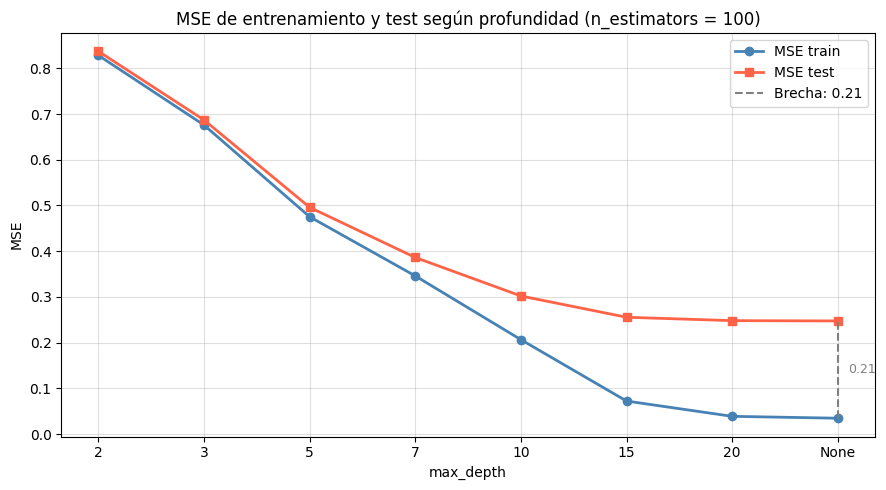

In [20]:
df_g1 = df[df["n_estimators"] == 100].groupby("profundidad")[["mse_train","mse_test"]].mean().reindex(orden_depth)
x = np.arange(len(orden_depth))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, df_g1["mse_train"], marker="o", color="steelblue", linewidth=2, label="MSE train")
ax.plot(x, df_g1["mse_test"],  marker="s", color="tomato",    linewidth=2, label="MSE test")

# Brecha en max_depth=None
idx_none = orden_depth.index("None")
y_train_none = df_g1["mse_train"].iloc[-1]
y_test_none  = df_g1["mse_test"].iloc[-1]
brecha = y_test_none - y_train_none

ax.vlines(idx_none, y_train_none, y_test_none,
          colors="gray", linestyles="dashed", linewidth=1.5, label=f"Brecha: {brecha:.2f}")
ax.annotate(f"{brecha:.2f}", xy=(idx_none + 0.1, (y_train_none + y_test_none) / 2),
            fontsize=9, color="gray", va="center")

ax.set_xticks(x)
ax.set_xticklabels(orden_depth)
ax.set_xlabel("max_depth")
ax.set_ylabel("MSE")
ax.set_title("MSE de entrenamiento y test según profundidad (n_estimators = 100)")
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout()
plt.show()


**Interpretación:** A medida que aumenta `max_depth`, el MSE de entrenamiento disminuye de forma continua. Esto es esperable, porque árboles más profundos pueden ajustarse mejor a los datos de entrenamiento.

El MSE de test también disminuye al principio, especialmente hasta `max_depth = 10`, pero luego tiende a estabilizarse alrededor de valores cercanos a 0.24. Esto indica que aumentar la profundidad mejora el desempeño hasta cierto punto, pero después las mejoras son cada vez menores.

Además, la diferencia entre el MSE de entrenamiento y el MSE de test crece con la profundidad. Esto sugiere que los árboles más profundos ajustan mucho mejor el conjunto de entrenamiento que el conjunto de prueba, lo que puede interpretarse como una señal de sobreajuste. Sin embargo, como el MSE de test no aumenta claramente, el Random Forest logra controlar parcialmente ese sobreajuste mediante el promedio de muchos árboles.


### Gráfico 2 — MSE de test y tiempo de entrenamiento según cantidad de árboles

Fijando `max_depth=10`, se muestra el trade-off entre desempeño predictivo y costo computacional
al variar `n_estimators`.


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/figures/g2_mse_tiempo_vs_estimators.png'

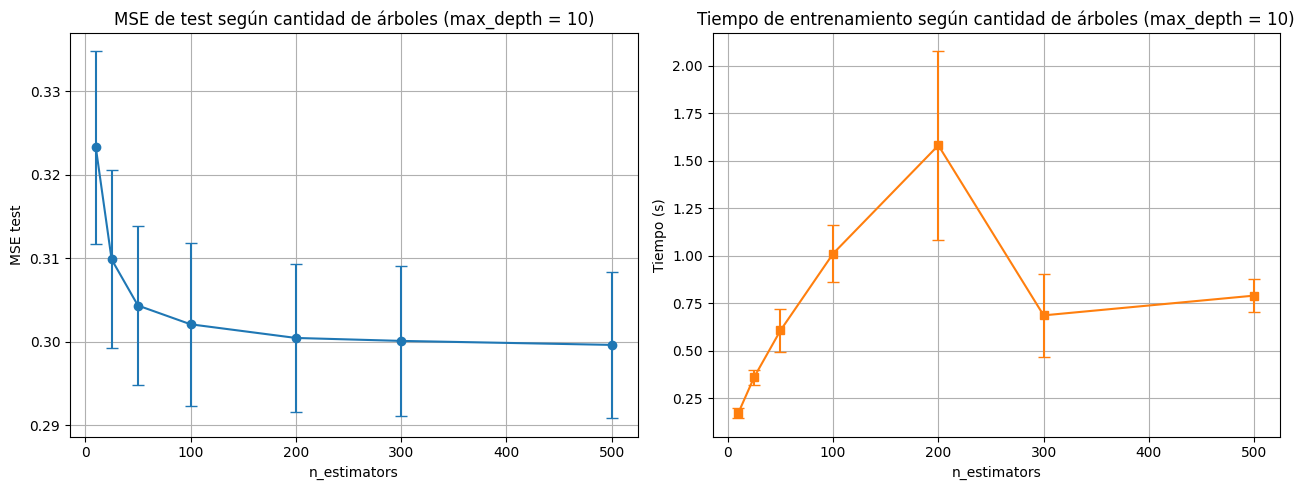

In [21]:
df_g2 = df[df["profundidad"]=="10"].groupby("n_estimators")[["mse_test","tiempo_s"]].agg(["mean","std"]).reset_index().sort_values("n_estimators")
x2 = df_g2["n_estimators"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(x2, df_g2[("mse_test","mean")], yerr=df_g2[("mse_test","std")], marker="o", capsize=4)
axes[0].set_xlabel("n_estimators"); axes[0].set_ylabel("MSE test")
axes[0].set_title("MSE de test según cantidad de árboles (max_depth = 10)"); axes[0].grid(True)

axes[1].errorbar(x2, df_g2[("tiempo_s","mean")], yerr=df_g2[("tiempo_s","std")], marker="s", capsize=4, color="tab:orange")
axes[1].set_xlabel("n_estimators"); axes[1].set_ylabel("Tiempo (s)")
axes[1].set_title("Tiempo de entrenamiento según cantidad de árboles (max_depth = 10)"); axes[1].grid(True)

plt.tight_layout()
plt.savefig("outputs/figures/g2_mse_tiempo_vs_estimators.png", dpi=120)
plt.show()


**Interpretación:** Al fijar `max_depth = 10`, se observa que el MSE de test disminuye principalmente al pasar de pocos árboles a una cantidad intermedia. La mejora es más clara entre 10 y 50 árboles, y luego el error comienza a estabilizarse. A partir de aproximadamente 100 o 200 árboles, las mejoras son cada vez menores.

En cambio, el tiempo de entrenamiento aumenta de forma clara a medida que crece `n_estimators`, pasando de tiempos muy bajos con pocos árboles a valores mucho mayores con 500 árboles.

Esto muestra un compromiso entre desempeño y costo computacional: agregar más árboles puede mejorar levemente el error y estabilizar el modelo, pero después de cierto punto el beneficio predictivo es pequeño en relación con el aumento del tiempo de entrenamiento.

### Gráfico 3 — MSE de test por profundidad para cada cantidad de árboles

Permite comparar el efecto de `n_estimators` dentro de cada nivel de `max_depth`.


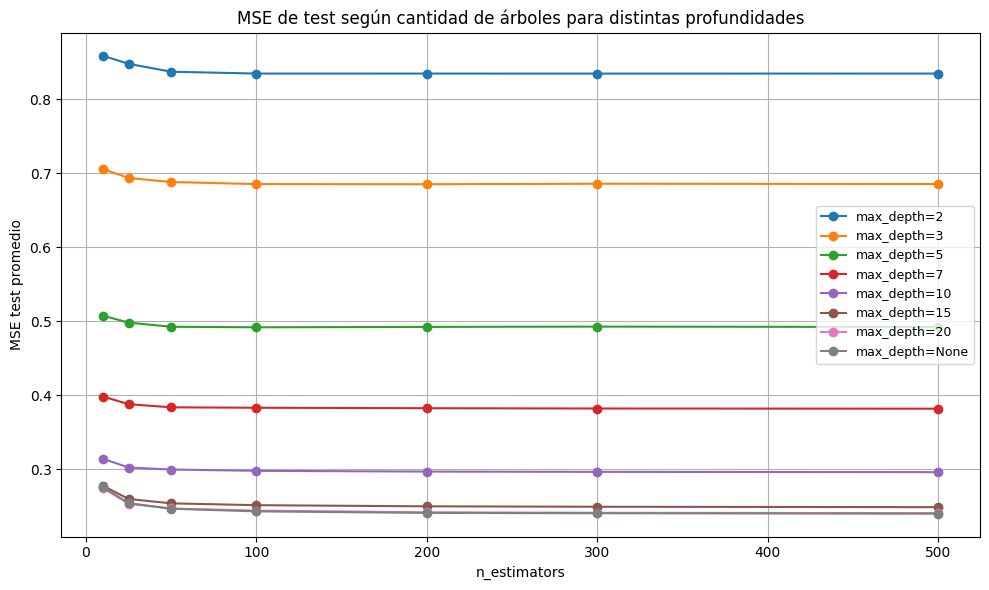

In [ ]:
resumen_g4 = df.groupby(["profundidad","n_estimators"])["mse_test"].mean().reset_index()

plt.figure(figsize=(10, 6))
for prof in orden_depth:
    sub = resumen_g4[resumen_g4["profundidad"]==prof].sort_values("n_estimators")
    plt.plot(sub["n_estimators"], sub["mse_test"], marker="o", label=f"max_depth={prof}")

plt.xlabel("n_estimators"); plt.ylabel("MSE test promedio")
plt.title("MSE de test según cantidad de árboles para distintas profundidades")
plt.legend(fontsize=9); plt.grid(True); plt.tight_layout()
plt.savefig("outputs/figures/g4_mse_por_depth.png", dpi=120)
plt.show()


**Interpretación:** El gráfico muestra que el MSE de test depende principalmente de la profundidad máxima de los árboles. Las curvas con profundidades bajas, como `max_depth = 2` y `max_depth = 3`, se ubican claramente por encima del resto, lo que indica un mayor error de predicción y posible subajuste.

Al aumentar la profundidad, el MSE de test disminuye de forma marcada. Sin embargo, a partir de profundidades altas, como `max_depth = 15`, `20` o `None`, las curvas se superponen casi por completo. Esto indica que permitir árboles aún más profundos ya no produce mejoras relevantes.

Por otro lado, aumentar `n_estimators` reduce levemente el MSE de test al comienzo, pero luego las curvas se estabilizan. Por lo tanto, agregar más árboles puede mejorar la estabilidad del modelo, aunque después de cierto punto las mejoras son marginales.

### Gráfico 4 — Descomposición sesgo² + varianza + error irreducible

La componente que domina el error total a lo largo de la grilla de `max_depth`.


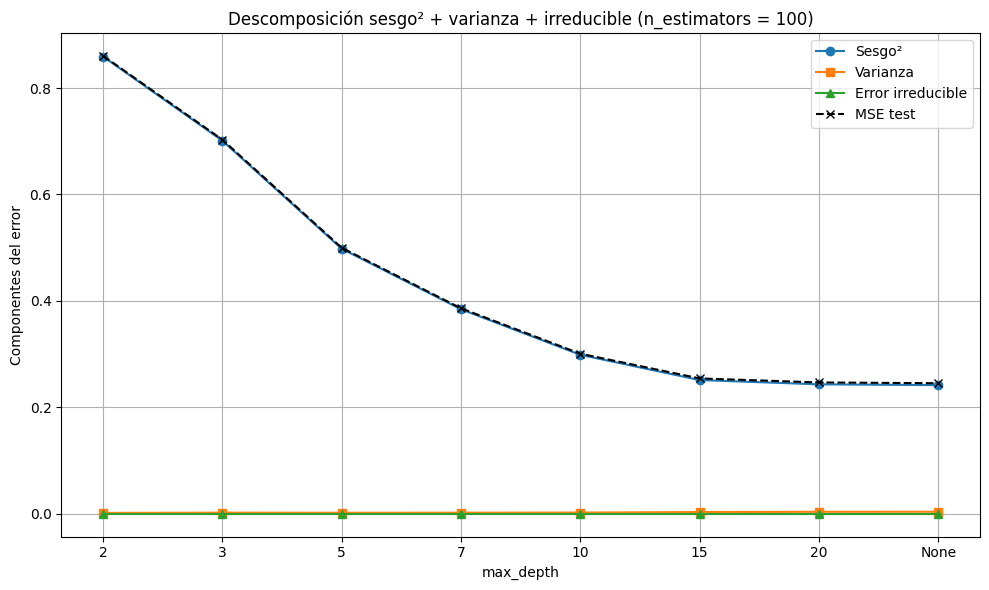

In [ ]:
df_sv_plot = df_sv_depth.copy()
df_sv_plot["orden"] = df_sv_plot["depth"].apply(lambda s: orden_depth.index(s))
df_sv_plot = df_sv_plot.sort_values("orden")
x5 = np.arange(len(df_sv_plot))

plt.figure(figsize=(10, 6))
plt.plot(x5, df_sv_plot["bias2"],      marker="o", label="Sesgo²")
plt.plot(x5, df_sv_plot["varianza"],   marker="s", label="Varianza")
plt.plot(x5, df_sv_plot["irreducible"],marker="^", label="Error irreducible")
plt.plot(x5, df_sv_plot["mse_test"],   marker="x", linestyle="--", color="black", label="MSE test")
plt.xticks(x5, df_sv_plot["depth"])
plt.xlabel("max_depth"); plt.ylabel("Componentes del error")
plt.title("Descomposición sesgo² + varianza + irreducible (n_estimators = 100)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("outputs/figures/g5_sesgo_varianza.png", dpi=120)
plt.show()


**Interpretación:** El gráfico muestra que el MSE de test sigue una trayectoria muy similar al sesgo². Esto indica que, bajo esta estimación empírica, la principal componente del error es el sesgo del modelo.

Cuando `max_depth` es bajo, los árboles son demasiado simples y el sesgo² es alto, lo que sugiere subajuste. Al aumentar la profundidad, el modelo gana flexibilidad y el sesgo² disminuye junto con el MSE de test.

La varianza estimada se mantiene baja en comparación con el sesgo², lo cual es consistente con el efecto estabilizador de Random Forest al promediar muchos árboles. El error irreducible aparece prácticamente nulo en esta descomposición, pero no debe interpretarse como ausencia real de ruido en el problema, sino como resultado de la forma en que fue estimado.

### Gráfico 5 — Distribución del MSE de test por profundidad (boxplots)

Variabilidad del MSE de test entre las 30 réplicas para cada valor de `max_depth`.


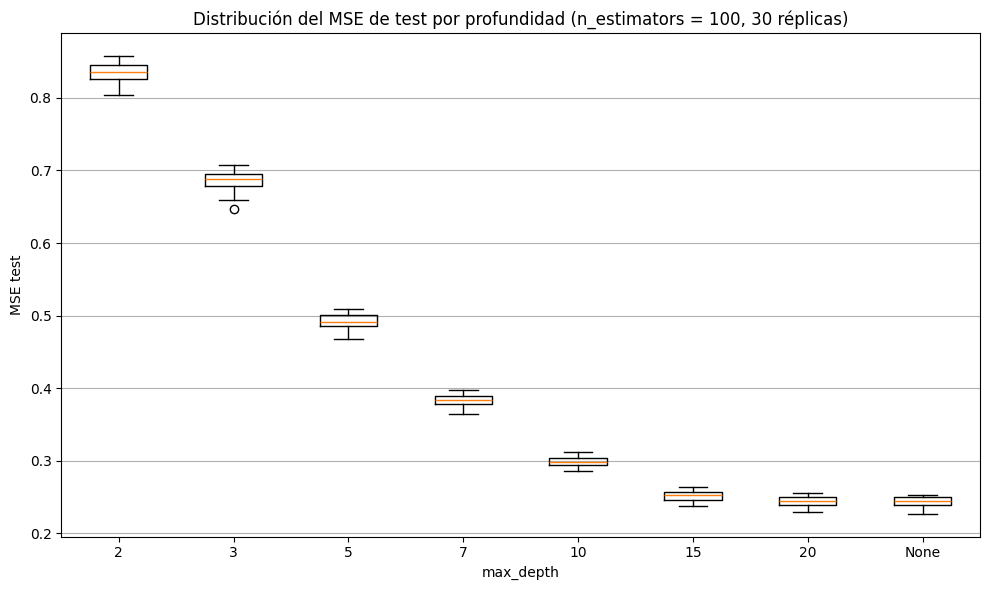

In [ ]:
df_g6 = df[df["n_estimators"]==100]
grupos   = [df_g6[df_g6["profundidad"]==p]["mse_test"].values for p in orden_depth]

plt.figure(figsize=(10, 6))
try:
    plt.boxplot(grupos, tick_labels=orden_depth)
except TypeError:
    plt.boxplot(grupos, labels=orden_depth)
plt.xlabel("max_depth"); plt.ylabel("MSE test")
plt.title("Distribución del MSE de test por profundidad (n_estimators = 100, 30 réplicas)")
plt.grid(True, axis="y"); plt.tight_layout()
plt.savefig("outputs/figures/g6_boxplot_depth.png", dpi=120)
plt.show()


**Interpretación:** Los boxplots muestran la distribución del MSE de test para cada valor de `max_depth` a lo largo de las 30 réplicas de simulación.

Se observa que las profundidades bajas, especialmente `max_depth = 2` y `max_depth = 3`, presentan valores de MSE claramente más altos. Esto indica que árboles demasiado simples no logran capturar adecuadamente la relación entre las variables predictoras y el valor de la vivienda, lo que sugiere subajuste.

A medida que aumenta la profundidad, el MSE de test disminuye de forma marcada. Sin embargo, a partir de profundidades altas, como `max_depth = 15`, `20` o `None`, las distribuciones se vuelven muy similares. Esto indica que permitir árboles aún más profundos produce mejoras pequeñas o marginales.

Además, las cajas son relativamente angostas, especialmente en profundidades medias y altas, lo que muestra que los resultados son bastante estables entre réplicas.


## Conclusiones

### Respuesta a las hipótesis

**H1 — Efecto de `max_depth` sobre el MSE de test: confirmada parcialmente.**
La hipótesis planteaba que, al aumentar la profundidad máxima de los árboles, el MSE de test primero disminuiría y luego podría aumentar por sobreajuste. En los resultados, el MSE de test efectivamente disminuye de manera marcada al pasar de profundidades bajas a profundidades medias y altas. Sin embargo, no se observa un aumento posterior claro del error, sino una estabilización a partir de valores altos como `max_depth = 15`, `20` o `None`. Esto se debe a que el Random Forest promedia las predicciones de 100 árboles. Cada árbol sobreajustado comete errores distintos entre sí, y al promediarlos esos errores se compensan. Por eso el sobreajuste individual de cada árbol no se traslada al error final del modelo.

Esto indica que profundidades bajas generan subajuste, porque los árboles son demasiado simples para capturar la relación entre las variables y el valor de la vivienda. Al aumentar la profundidad, el modelo gana flexibilidad y mejora su desempeño. A partir de cierto punto, seguir aumentando la profundidad produce mejoras muy pequeñas.

**H2 — Rendimientos decrecientes de `n_estimators`: confirmada.**
El MSE de test disminuye principalmente al pasar de pocos árboles a una cantidad intermedia. Luego, a partir de aproximadamente 100 o 200 árboles, las mejoras se vuelven marginales. Esto muestra que agregar árboles ayuda a estabilizar el modelo, pero no mejora indefinidamente el desempeño.

**H3 — Crecimiento del tiempo de forma aproximadamente lineal de entrenamiento con `n_estimators`: confirmada.**
El tiempo de entrenamiento aumenta al incrementar la cantidad de árboles. Esto es esperable, ya que Random Forest debe construir más árboles a medida que aumenta `n_estimators`. Por lo tanto, aunque agregar árboles puede mejorar levemente el desempeño, también implica un mayor costo computacional.

### Conclusión general

El estudio muestra que Random Forest es un modelo adecuado para predecir el valor medio de viviendas en el dataset California Housing. El hiperparámetro más importante fue `max_depth`, porque controla la complejidad de los árboles y tiene un efecto claro sobre el MSE de test.

Con profundidades bajas, como `max_depth = 2` o `3`, el modelo presenta errores altos, lo que indica subajuste. Al aumentar la profundidad, el MSE de test disminuye porque el modelo puede capturar relaciones más complejas entre las variables predictoras y el valor de la vivienda. Sin embargo, a partir de profundidades altas, las mejoras se vuelven cada vez menores.

Por otro lado, `n_estimators` también influye en el desempeño, pero de forma más limitada. Agregar árboles mejora el error principalmente al comienzo, pero después aparecen rendimientos decrecientes. Además, el tiempo de entrenamiento aumenta con la cantidad de árboles, por lo que no siempre conviene usar valores demasiado altos.

En conjunto, los resultados muestran que el mejor modelo no necesariamente es el más complejo. Una configuración como `max_depth = 10` puede interpretarse como un punto de equilibrio razonable: reduce mucho el error frente a modelos simples, pero evita aumentar innecesariamente la complejidad. Si el objetivo fuera minimizar estrictamente el MSE, profundidades mayores podrían obtener valores levemente mejores; sin embargo, si se busca equilibrio entre desempeño, complejidad y costo computacional, una profundidad intermedia resulta defendible.
